# Session 3: Large Language Models

Large language models (LLMs) are neural networks trained to predict the next token in a sequence, but that simple objective produces surprisingly broad capabilities: text generation, question answering, summarization, translation, and instruction following. In practice, modern LLM workflows often combine three stages: loading a pretrained model, measuring how it performs on a specific task, and then finetuning it so the model adapts to the language patterns and outputs we want.

In this session we will build a compact end-to-end workflow around a small chat model:

1. **Load a pretrained language model** and its tokenizer from Hugging Face.
2. **Turn a labeled dataset into an instruction-following task** so that evaluation is easy to interpret.
3. **Evaluate the pretrained model** on a held-out split.
4. **Finetune the model with LoRA** on a small subset and compare performance before and after training.
5. **Make a live OpenAI API call** and inspect the returned answer.

By the end of the notebook you will have seen the core lifecycle of many practical LLM systems: pretrained model, task-specific adaptation, quantitative comparison, and API-based inference with a hosted frontier model.

## 0. Setup

We will use **Transformers** for model loading, **datasets** for data access, **PEFT** for parameter-efficient finetuning, and **Matplotlib** for a small comparison plot. Because TinyLlama is still much larger than the models in the earlier notebooks, a CUDA GPU is strongly recommended for the finetuning section. We also redirect the Hugging Face cache to a writable runtime directory: `/content/hf_cache` in Google Colab, or a local cache directory when running elsewhere.

The final section uses the OpenAI API. Before running that cell, make sure your shell or notebook environment has `OPENAI_API_KEY` set.

In [1]:
! pip install -q transformers datasets accelerate peft trl openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.0/531.0 kB 11.1 MB/s eta 0:00:00


In [2]:
%matplotlib inline

import inspect
import os
import random
import re
from pathlib import Path

IN_COLAB = 'google.colab' in str(get_ipython())
RUNTIME_ROOT = Path('/content' if IN_COLAB else '.').resolve()
HF_CACHE_ROOT = RUNTIME_ROOT / 'hf_cache'
HF_HUB_CACHE = HF_CACHE_ROOT / 'hub'
HF_DATASETS_CACHE = HF_CACHE_ROOT / 'datasets'
OUTPUT_ROOT = RUNTIME_ROOT / 'artifacts'

HF_HUB_CACHE.mkdir(parents=True, exist_ok=True)
HF_DATASETS_CACHE.mkdir(parents=True, exist_ok=True)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

os.environ['HF_HOME'] = str(HF_CACHE_ROOT)
os.environ['HUGGINGFACE_HUB_CACHE'] = str(HF_HUB_CACHE)
os.environ['HF_HUB_CACHE'] = str(HF_HUB_CACHE)
os.environ['TRANSFORMERS_CACHE'] = str(HF_HUB_CACHE)
os.environ['HF_DATASETS_CACHE'] = str(HF_DATASETS_CACHE)

import matplotlib.pyplot as plt
import torch
from datasets import load_dataset
from peft import LoraConfig, TaskType, get_peft_model
from transformers import AutoModelForCausalLM, AutoTokenizer, Trainer, TrainingArguments, default_data_collator

SEED = 0
random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type != 'cuda':
    print('A CUDA GPU is strongly recommended for TinyLlama finetuning.')
print(f'Runtime root: {RUNTIME_ROOT}')
print(f'Hugging Face cache: {HF_CACHE_ROOT}')
print(f'Artifacts directory: {OUTPUT_ROOT}')

Using device: cuda
Runtime root: /content
Hugging Face cache: /content/hf_cache
Artifacts directory: /content/artifacts


---

## 1. Load a Small Chat Model and Tokenizer

We will work with **TinyLlama-1.1B-Chat**, a compact instruction-tuned causal language model. It is small enough to demonstrate the standard LLM workflow in a classroom notebook while still behaving like a modern chat model: we pass it structured messages, generate text autoregressively, and later adapt it with a lightweight finetuning method.

We also define a small prompt template for sentiment classification. The model will be asked to answer with exactly one label: `positive` or `negative`.

In [3]:
model_name = 'TinyLlama/TinyLlama-1.1B-Chat-v1.0'
label_names = {0: 'negative', 1: 'positive'}
SYSTEM_PROMPT = 'You are a careful sentiment classifier. Reply with exactly one word: positive or negative.'

tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'right'

torch_dtype = torch.float16 if device.type == 'cuda' else torch.float32
base_model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch_dtype)
base_model.to(device)
base_model.eval()

def render_messages(messages, add_generation_prompt=False):
    if tokenizer.chat_template is not None:
        return tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=add_generation_prompt,
        )

    prompt = ''
    for message in messages:
        prompt += f"{message['role'].upper()}: {message['content']}\n"
    if add_generation_prompt:
        prompt += 'ASSISTANT: '
    return prompt

def build_user_prompt(sentence):
    return (
        f"Classify the sentiment of this movie review as positive or negative.\n"
        f"Review: {sentence}\n"
        'Answer with exactly one word: positive or negative.'
    )

preview_prompt = render_messages(
    [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': build_user_prompt('A warm, funny, and surprisingly moving film.')},
    ],
    add_generation_prompt=True,
)
print(preview_prompt[:700])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

<|system|>
You are a careful sentiment classifier. Reply with exactly one word: positive or negative.</s>
<|user|>
Classify the sentiment of this movie review as positive or negative.
Review: A warm, funny, and surprisingly moving film.
Answer with exactly one word: positive or negative.</s>
<|assistant|>



## 2. Load and Inspect a Dataset

To make the evaluation step precise, we will use the **SST-2** sentiment dataset from the GLUE benchmark. This dataset contains short movie-review sentences labeled as either positive or negative. Although SST-2 is not an instruction dataset by itself, we can easily convert it into one by wrapping each sentence in a short prompt.

This is a useful pattern in practice: take a standard supervised dataset and reformat it into prompt/response pairs so that a generative model can be trained and evaluated with the same interface it uses at inference time.

In [4]:
raw_dataset = load_dataset('glue', 'sst2')

# Keep the run lightweight enough for a teaching notebook.
train_dataset = raw_dataset['train'].shuffle(seed=SEED).select(range(256))
eval_dataset = raw_dataset['validation'].select(range(32))

print(f'Train examples: {len(train_dataset)}')
print(f'Eval examples: {len(eval_dataset)}')
print()
print('Example sentence:')
print(train_dataset[0]['sentence'])
print('Gold label:', label_names[int(train_dataset[0]['label'])])

README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Train examples: 256
Eval examples: 32

Example sentence:
empty stud knockabout 
Gold label: negative


## 3. Evaluate the Pretrained Model

Before training, we need a baseline. We will prompt the pretrained chat model with a sentiment-classification instruction and ask it to produce a short answer. Because the task has only two valid outputs, we can compute a simple and interpretable metric: **accuracy**.

The evaluation function below scores the two valid label completions directly instead of relying on open-ended generation. That makes the baseline much more stable, and we will reuse the exact same evaluation logic after finetuning.

In [5]:
candidate_label_ids = {
    label: tokenizer.encode(label, add_special_tokens=False)
    for label in label_names.values()
}

@torch.no_grad()
def score_label_candidates(model, sentence):
    prompt_text = render_messages(
        [
            {'role': 'system', 'content': SYSTEM_PROMPT},
            {'role': 'user', 'content': build_user_prompt(sentence)},
        ],
        add_generation_prompt=True,
    )

    prompt_inputs = tokenizer(prompt_text, return_tensors='pt').to(device)
    prompt_len = prompt_inputs['input_ids'].shape[1]
    scores = {}

    for label, label_ids in candidate_label_ids.items():
        label_tensor = torch.tensor([label_ids], device=device)
        input_ids = torch.cat([prompt_inputs['input_ids'], label_tensor], dim=1)
        attention_mask = torch.cat(
            [prompt_inputs['attention_mask'], torch.ones_like(label_tensor)],
            dim=1,
        )
        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits[0]

        total_logprob = 0.0
        for idx, token_id in enumerate(label_ids):
            token_position = prompt_len + idx
            token_logits = logits[token_position - 1]
            total_logprob += torch.log_softmax(token_logits, dim=-1)[token_id].item()

        scores[label] = total_logprob

    prediction = max(scores, key=scores.get)
    return prediction, scores

def evaluate_model(model, dataset, limit=None):
    rows = []
    subset = dataset.select(range(min(limit, len(dataset)))) if limit is not None else dataset

    for example in subset:
        gold = label_names[int(example['label'])]
        pred, scores = score_label_candidates(model, example['sentence'])
        rows.append({
            'sentence': example['sentence'],
            'gold': gold,
            'pred': pred,
            'scores': scores,
            'correct': pred == gold,
        })

    accuracy = sum(row['correct'] for row in rows) / len(rows)
    return accuracy, rows

baseline_accuracy, baseline_rows = evaluate_model(base_model, eval_dataset)
print(f'Pretrained accuracy: {baseline_accuracy:.3f}')
print()
for row in baseline_rows[:5]:
    print(f"gold={row['gold']:<8} pred={row['pred']:<8} scores={row['scores']}")
    print(f"sentence={row['sentence']}\n")

Pretrained accuracy: 0.438

gold=positive pred=positive scores={'negative': -11.0234375, 'positive': -8.203125}
sentence=it 's a charming and often affecting journey . 

gold=negative pred=positive scores={'negative': -11.09375, 'positive': -8.5703125}
sentence=unflinchingly bleak and desperate 

gold=positive pred=positive scores={'negative': -11.078125, 'positive': -8.4921875}
sentence=allows us to hope that nolan is poised to embark a major career as a commercial yet inventive filmmaker . 

gold=positive pred=positive scores={'negative': -10.609375, 'positive': -7.9921875}
sentence=the acting , costumes , music , cinematography and sound are all astounding given the production 's austere locales . 

gold=negative pred=positive scores={'negative': -11.0078125, 'positive': -8.671875}
sentence=it 's slow -- very , very slow . 



## 4. Finetune the Model on a Small Subset

A full finetune updates every parameter in the model, which is often expensive. Instead, we will use **LoRA** (Low-Rank Adaptation), a parameter-efficient finetuning method that inserts a small number of trainable matrices into key attention projections. This keeps memory use lower and makes the training step practical for a short notebook.

We convert each labeled example into a prompt plus the correct one-word answer. During training we mask the prompt tokens in the loss so that the model is only penalized for the assistant response.

In [6]:
MAX_LENGTH = 256

def build_training_text(example):
    gold_label = label_names[int(example['label'])]
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': build_user_prompt(example['sentence'])},
        {'role': 'assistant', 'content': gold_label},
    ]
    return render_messages(messages, add_generation_prompt=False)

def tokenize_supervised_example(example):
    prompt_text = render_messages(
        [
            {'role': 'system', 'content': SYSTEM_PROMPT},
            {'role': 'user', 'content': build_user_prompt(example['sentence'])},
        ],
        add_generation_prompt=True,
    )
    full_text = build_training_text(example)

    prompt_ids = tokenizer(prompt_text, add_special_tokens=False).input_ids
    tokenized = tokenizer(
        full_text,
        truncation=True,
        max_length=MAX_LENGTH,
        padding='max_length',
    )
    labels = tokenized['input_ids'].copy()
    prompt_length = min(len(prompt_ids), MAX_LENGTH)
    labels[:prompt_length] = [-100] * prompt_length
    labels = [token if token != tokenizer.pad_token_id else -100 for token in labels]
    tokenized['labels'] = labels
    return tokenized

train_tokenized = train_dataset.map(tokenize_supervised_example, remove_columns=train_dataset.column_names)

# The baseline metrics are already stored, so free memory before LoRA training.
del base_model
if device.type == 'cuda':
    torch.cuda.empty_cache()

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias='none',
    target_modules=['q_proj', 'v_proj'],
)

finetuned_model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch_dtype)
finetuned_model.to(device)
finetuned_model.config.use_cache = False
finetuned_model = get_peft_model(finetuned_model, lora_config)
finetuned_model.print_trainable_parameters()

training_kwargs = {
    'output_dir': str(OUTPUT_ROOT / 'tinyllama_lora_sst2'),
    'num_train_epochs': 1,
    'per_device_train_batch_size': 4 if device.type == 'cuda' else 1,
    'gradient_accumulation_steps': 4,
    'learning_rate': 2e-4,
    'logging_steps': 10,
    'save_strategy': 'no',
    'report_to': 'none',
    'fp16': device.type == 'cuda',
    'remove_unused_columns': False,
}
supported_args = inspect.signature(TrainingArguments.__init__).parameters
training_args = TrainingArguments(**{k: v for k, v in training_kwargs.items() if k in supported_args})

trainer = Trainer(
    model=finetuned_model,
    args=training_args,
    train_dataset=train_tokenized,
    data_collator=default_data_collator,
)

trainer.train()
finetuned_model.eval()

Map:   0%|          | 0/256 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

trainable params: 1,126,400 || all params: 1,101,174,784 || trainable%: 0.1023


Step,Training Loss
10,1.004831


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(32000, 2048)
        (layers): ModuleList(
          (0-21): 22 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=2048, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): Linear(in_feat

## 5. Evaluate Again and Compare Results

Now we rerun the same held-out evaluation on the finetuned model. Because the prompts and metric are unchanged, any difference in accuracy is directly attributable to the task-specific adaptation step rather than a change in evaluation procedure.

For a compact visual summary, we plot the pretrained and finetuned accuracies side by side.

Pretrained accuracy: 0.438
Finetuned accuracy : 0.562
Improvement         : +0.125


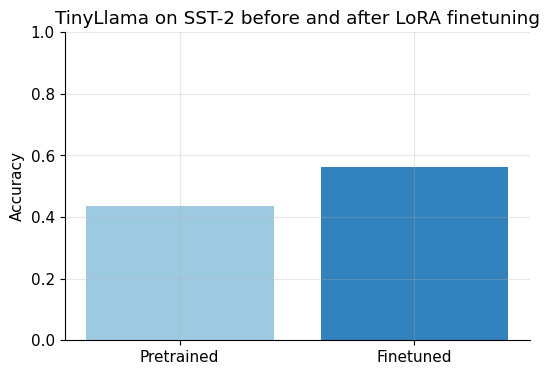

Examples fixed by finetuning: 7

Sentence: it 's slow -- very , very slow . 
Before: pred=positive scores={'negative': -11.0078125, 'positive': -8.671875}
After : pred=negative scores={'negative': -8.228816986083984, 'positive': -8.814754486083984}
Gold  : negative

Sentence: or doing last year 's taxes with your ex-wife . 
Before: pred=positive scores={'negative': -10.859375, 'positive': -8.3671875}
After : pred=negative scores={'negative': -7.8380632400512695, 'positive': -8.06462574005127}
Gold  : negative

Sentence: ... the film suffers from a lack of humor ( something needed to balance out the violence ) ... 
Before: pred=positive scores={'negative': -10.4921875, 'positive': -8.1171875}
After : pred=negative scores={'negative': -8.145282745361328, 'positive': -8.160907745361328}
Gold  : negative


In [7]:
finetuned_accuracy, finetuned_rows = evaluate_model(finetuned_model, eval_dataset)

print(f'Pretrained accuracy: {baseline_accuracy:.3f}')
print(f'Finetuned accuracy : {finetuned_accuracy:.3f}')
print(f'Improvement         : {finetuned_accuracy - baseline_accuracy:+.3f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Pretrained', 'Finetuned'], [baseline_accuracy, finetuned_accuracy], color=['#9ecae1', '#3182bd'])
ax.set_ylim(0.0, 1.0)
ax.set_ylabel('Accuracy')
ax.set_title('TinyLlama on SST-2 before and after LoRA finetuning')
plt.show()

improved_examples = [
    (before, after)
    for before, after in zip(baseline_rows, finetuned_rows)
    if (not before['correct']) and after['correct']
]

print(f'Examples fixed by finetuning: {len(improved_examples)}')
for before, after in improved_examples[:3]:
    print()
    print('Sentence:', before['sentence'])
    print(f"Before: pred={before['pred']} scores={before['scores']}")
    print(f"After : pred={after['pred']} scores={after['scores']}")
    print(f"Gold  : {before['gold']}")

## 6. Call the OpenAI API and Inspect a Sample Response

Open-source models and hosted APIs fit different use cases. Finetuning a local model gives you direct control over training and evaluation, while a hosted API gives fast access to a stronger general-purpose model without managing checkpoints yourself.

The cell below uses the modern `OpenAI` Python client. It makes a live request, prints the returned text, and will raise a clear error if `OPENAI_API_KEY` is missing.

In [ ]:
from openai import OpenAI

if 'OPENAI_API_KEY' not in os.environ:
    raise RuntimeError('Set OPENAI_API_KEY before running this cell.')

client = OpenAI()
response = client.responses.create(
    model='gpt-4.1-mini',
    input='In 3 sentences, explain why finetuning can improve task-specific performance for a small language model.',
)

print(response.output_text)